# EmporiUm Sales Territory Analysis

Analysis of in-store sales for **Territory manager: Ellen Lemon (Connecticut)** 

The goal is to identify trends, top performers, and actionable insights from the provided datasets.

Data covers sales transactions, products, and customer rewards data.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Loading the data

In [51]:
# store detail
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [52]:
# store sales
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [53]:
# products
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [54]:
# categories 
categories = pd.read_csv('ProductCategories.csv')
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [55]:
# Customer data
customers = pd.read_csv('customer_list.csv')
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


In [56]:
customers.head()

,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


## Core Marketing Analysis

### (a) Who are the territory managers and what stores are in each territory?

In [57]:
# filtering storedetails for my territory
# and replacing the territory manager names 
t1 = store_detail[store_detail['Territory Manager'] == 'Ellen Lemon']

print('Territory 1 - Ellen Lemon (Connecticut)')
print(t1[['Store ID', 'Store Location', 'Territory Manager']])
print()

Territory 1 - Ellen Lemon (Connecticut)
    Store ID     Store Location Territory Manager
18       865         Bridgeport       Ellen Lemon
19       866             Darien       Ellen Lemon
20       867           Hartford       Ellen Lemon
21       868  Litchfield County       Ellen Lemon
22       869          New Haven       Ellen Lemon
23       870         New London       Ellen Lemon
24       871       Old Saybrook       Ellen Lemon
25       872          Waterbury       Ellen Lemon



In [60]:
# filtering storedetails for my territory
# and replacing the territory manager names 
t2 = store_detail[store_detail['Territory Manager'] == 'See Ellefson']

print('Territory 2 - See Ellefson (New York)')
print(t2[['Store ID', 'Store Location', 'Territory Manager']])
print()

Territory 2 - See Ellefson (New York)
    Store ID Store Location Territory Manager
86       840         Albany      See Ellefson
87       841        Buffalo      See Ellefson
88       842         Elmira      See Ellefson
89       843         Ithaca      See Ellefson
90       844         Oswego      See Ellefson
91       845    Plattsburgh      See Ellefson
92       846    Poestenkill      See Ellefson
93       847      Rochester      See Ellefson
94       848       Syracuse      See Ellefson
95       849       Brooklyn      See Ellefson
96       850       New York      See Ellefson
97       851         Queens      See Ellefson



In [61]:
# storing IDs for filtering

t1_store_ids = t1['Store ID'].tolist()
t2_store_ids = t2['Store ID'].tolist()

### (b) What is monthly total revenue for in-store sales in each territory?

In [64]:
# Converting transaction date to datetime and then filter out online sales (Store ID = 0 or NaN)

store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

instore = store_sales[store_sales['Store ID'].notna() & (store_sales['Store ID'] != 0)]

In [65]:
# Calculating monthly revenue for territory 1
t1_sales = instore[instore['Store ID'].isin(t1_store_ids)]

t1_monthly = t1_sales.groupby('Month')['Sale Amount'].sum().reset_index()
t1_monthly.columns =['Month', 'Revenue']


print('Territory 1 Monthly Revenue:')
print(t1_monthly)
print()

Territory 1 Monthly Revenue:
      Month    Revenue
0   2022-01   29958.25
1   2022-02   25563.98
2   2022-03   33995.57
3   2022-04   31587.12
4   2022-05   37953.48
5   2022-06   32008.85
6   2022-07   30656.27
7   2022-08   42881.99
8   2022-09   30369.64
9   2022-10   43646.37
10  2022-11   25950.41
11  2022-12   34680.64
12  2023-01   38351.45
13  2023-02   53435.37
14  2023-03   50828.54
15  2023-04   45747.20
16  2023-05   39215.78
17  2023-06   39754.07
18  2023-07   49592.69
19  2023-08   48445.34
20  2023-09   49175.79
21  2023-10   45347.65
22  2023-11   42683.73
23  2023-12   50446.82
24  2024-01   57974.76
25  2024-02   49206.33
26  2024-03   46044.68
27  2024-04   38918.30
28  2024-05   41203.81
29  2024-06   48142.95
30  2024-07   48445.34
31  2024-08   49633.16
32  2024-09   44890.28
33  2024-10   43061.44
34  2024-11   50069.11
35  2024-12   38351.45
36  2025-01   68601.89
37  2025-02   55131.75
38  2025-03   69261.43
39  2025-04   58288.72
40  2025-05   66996.15
41  2

In [66]:
# Calculating monthly revenue for territory 2
t2_sales = instore[instore['Store ID'].isin(t2_store_ids)]

t2_monthly = t2_sales.groupby('Month')['Sale Amount'].sum().reset_index()
t2_monthly.columns =['Month', 'Revenue']

print()
print('Territory 2 Monthly Revenue:')
print(t2_monthly)


Territory 2 Monthly Revenue:
      Month    Revenue
0   2022-01   58635.53
1   2022-02   60262.97
2   2022-03   57143.40
3   2022-04   56880.02
4   2022-05   51805.22
5   2022-06   60549.86
6   2022-07   56250.74
7   2022-08   55052.53
8   2022-09   60495.63
9   2022-10   56896.98
10  2022-11   58402.69
11  2022-12   55006.46
12  2023-01   85210.01
13  2023-02   86906.65
14  2023-03   79964.16
15  2023-04   97173.99
16  2023-05  101370.73
17  2023-06   83465.90
18  2023-07   90818.80
19  2023-08   89422.22
20  2023-09   89196.88
21  2023-10   85095.72
22  2023-11   79627.33
23  2023-12   75904.66
24  2024-01   94306.43
25  2024-02   75083.70
26  2024-03   99439.50
27  2024-04   99105.22
28  2024-05   87328.99
29  2024-06   86955.71
30  2024-07   89422.22
31  2024-08   91189.41
32  2024-09   83103.19
33  2024-10   80543.34
34  2024-11   74988.65
35  2024-12   85210.01
36  2025-01  135193.89
37  2025-02  104990.83
38  2025-03  119415.68
39  2025-04  117652.02
40  2025-05  119352.07
41  

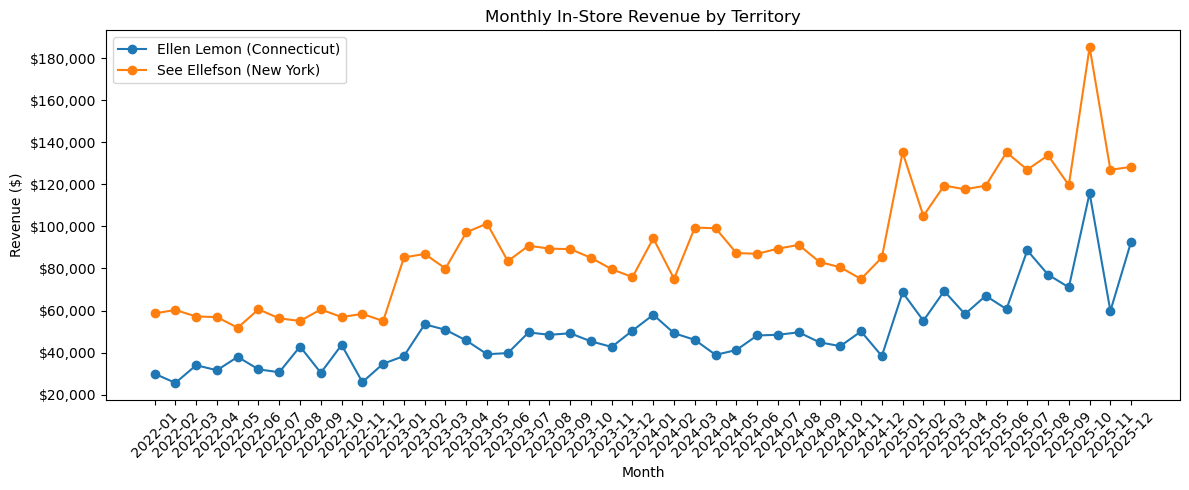

In [67]:
# Monthly revenue line chart

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t1_monthly['Month'].astype(str), t1_monthly['Revenue'], marker='o', label='Ellen Lemon (Connecticut)')
ax.plot(t2_monthly['Month'].astype(str), t2_monthly['Revenue'], marker='o', label='See Ellefson (New York)')
ax.set_title('Monthly In-Store Revenue by Territory')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### (c) How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

In [68]:
# Group sales by Store ID and rank

t1_by_store = t1_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
t1_by_store.columns = ['Store ID', 'Total Revenue']
t1_by_store = t1_by_store.merge(store_detail[['Store ID','Store Location']], on='Store ID')
t1_by_store = t1_by_store.sort_values('Total Revenue', ascending=False)
t1_by_store['Rank'] = range(1, len(t1_by_store)+1)
print('Territory 1 Store Rankings:')
print(t1_by_store[['Rank','Store Location','Total Revenue']])

Territory 1 Store Rankings:
   Rank     Store Location  Total Revenue
5     1         New London      331116.76
0     2         Bridgeport      322100.07
2     3           Hartford      309592.06
7     4          Waterbury      295651.17
4     5          New Haven      286779.43
3     6  Litchfield County      286217.15
1     7             Darien      283455.62
6     8       Old Saybrook      277310.18


In [69]:
# Group sales by Store ID and rank

t2_by_store = t2_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
t2_by_store.columns = ['Store ID', 'Total Revenue']
t2_by_store = t2_by_store.merge(store_detail[['Store ID','Store Location']], on='Store ID')
t2_by_store = t2_by_store.sort_values('Total Revenue', ascending=False)
t2_by_store['Rank'] = range(1, len(t2_by_store)+1)
print('Territory 2 Store Rankings:')
print(t2_by_store[['Rank','Store Location','Total Revenue']])

Territory 2 Store Rankings:
    Rank Store Location  Total Revenue
10     1       New York      621565.02
7      2      Rochester      607148.21
6      3    Poestenkill      334175.88
1      4        Buffalo      314979.99
2      5         Elmira      313971.65
3      6         Ithaca      313920.05
5      7    Plattsburgh      311520.52
0      8         Albany      310389.02
8      9       Syracuse      306998.14
9     10       Brooklyn      304732.76
4     11         Oswego      302862.71
11    12         Queens      288553.14


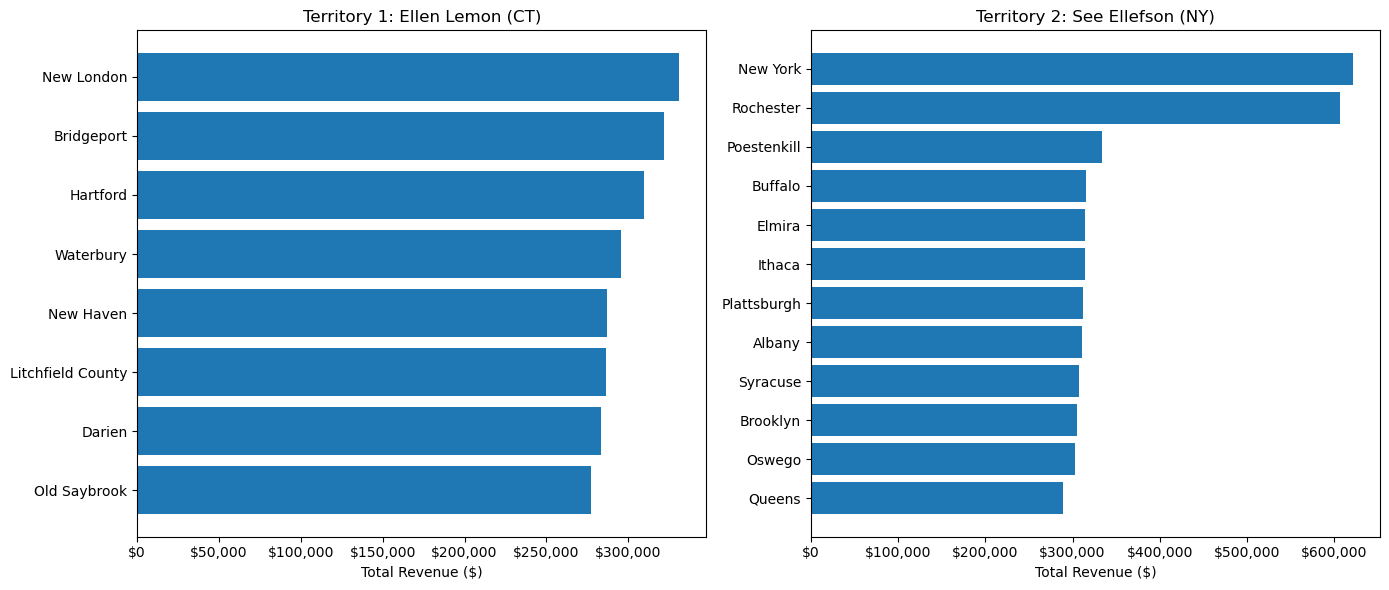

In [70]:
# Horizontal bar chart of store revenue

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title in zip(axes,
    [t1_by_store, t2_by_store],
    ['Territory 1: Ellen Lemon (CT)', 'Territory 2: See Ellefson (NY)']):
    ax.barh(data['Store Location'], data['Total Revenue'])
    ax.set_title(title)
    ax.set_xlabel('Total Revenue ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

From the graphs above, the top perfoming stores in territory 1 are **New London & Bridgeton**, and **New York & Rochester** in territoory 2

### (d) Who were the top customers in each territory?

In [71]:
customers = pd.read_csv('customer_list.csv', sep='|')
customers.columns = customers.columns.str.strip()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   cust_id      521 non-null    int64 
 1   date         521 non-null    object
 2   time         521 non-null    object
 3   name         521 non-null    object
 4   email        521 non-null    object
 5   phone        520 non-null    object
 6   sms-opt-out  520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [74]:
# Merging RewardsID with customer list
# The customer_list uses cust_id; StoreSales uses RewardsID

t1_rewards = t1_sales.groupby('RewardsID')['Sale Amount'].sum().reset_index()
t1_rewards.columns = ['cust_id', 'Total Spent']
t1_rewards['cust_id'] = t1_rewards['cust_id'].astype(str)
customers['cust_id'] = customers['cust_id'].astype(str)

t1_top = t1_rewards.merge(customers[['cust_id','name','email']], on='cust_id', how='left')
t1_top = t1_top.sort_values('Total Spent', ascending=False).head(10)
print('Top 10 Customers - Territory 1:')
print(t1_top)

Top 10 Customers - Territory 1:
    cust_id  Total Spent name email
17     18.0      4388.87  NaN   NaN
20     21.0      3676.21  NaN   NaN
311   322.0      3569.60  NaN   NaN
351   365.0      3009.29  NaN   NaN
98    104.0      2886.72  NaN   NaN
497   519.0      2766.60  NaN   NaN
327   340.0      2691.89  NaN   NaN
276   286.0      2624.61  NaN   NaN
187   197.0      2496.08  NaN   NaN
451   471.0      2376.77  NaN   NaN


In [75]:
# Merging RewardsID with customer list

t2_rewards = t2_sales.groupby('RewardsID')['Sale Amount'].sum().reset_index()
t2_rewards.columns = ['cust_id', 'Total Spent']
t2_rewards['cust_id'] = t2_rewards['cust_id'].astype(str)

t2_top = t2_rewards.merge(customers[['cust_id','name','email']], on='cust_id', how='left')
t2_top = t2_top.sort_values('Total Spent', ascending=False).head(10)
print('Top 10 Customers - Territory 2:')
print(t2_top)

Top 10 Customers - Territory 2:
    cust_id  Total Spent name email
299   300.0      6039.32  NaN   NaN
128   129.0      3918.72  NaN   NaN
187   188.0      3805.61  NaN   NaN
482   483.0      3504.20  NaN   NaN
198   199.0      3441.19  NaN   NaN
66     67.0      3426.57  NaN   NaN
203   204.0      3348.62  NaN   NaN
334   335.0      3280.21  NaN   NaN
151   152.0      3213.63  NaN   NaN
80     81.0      3159.40  NaN   NaN


The top customers were Customer ID:18 from terrritory 1, and Customer ID:300 from territory 2

### (e) Transactions and revenue by product category per month

In [76]:
# Merging sales with products and categories
sales_products = instore.merge(products[['Prod Num','CategoryID']], on='Prod Num', how='left')
sales_products = sales_products.merge(categories[['CategoryID','Category']].drop_duplicates(), on='CategoryID', how='left')

In [77]:
# Transactions per month by category — Territory 1

t1_cat = sales_products[sales_products['Store ID'].isin(t1_store_ids)]
t1_cat_monthly = t1_cat.groupby(['Month','Category']).agg(
    Transactions=('Sale Amount','count'),
    Revenue=('Sale Amount','sum')
).reset_index()
print(t1_cat_monthly)

       Month                  Category  Transactions   Revenue
0    2022-01   Apparel and Merchandise            42   1223.25
1    2022-01              Art Supplies            29    653.12
2    2022-01           Books (General)            19    489.60
3    2022-01   Stationery and Supplies            36    334.49
4    2022-01  Technology & Accessories            45  21860.06
..       ...                       ...           ...       ...
283  2025-12              Art Supplies            91   2969.29
284  2025-12           Books (General)            40   1399.52
285  2025-12   Stationery and Supplies           106   1073.41
286  2025-12  Technology & Accessories           132  74810.44
287  2025-12                 Textbooks            55   8793.17

[288 rows x 4 columns]


In [78]:
# Transactions per month by category — Territory 2

t2_cat = sales_products[sales_products['Store ID'].isin(t2_store_ids)]
t2_cat_monthly = t2_cat.groupby(['Month','Category']).agg(
    Transactions=('Sale Amount','count'),
    Revenue=('Sale Amount','sum')
).reset_index()
print(t2_cat_monthly)

       Month                  Category  Transactions   Revenue
0    2022-01   Apparel and Merchandise            66   2204.15
1    2022-01              Art Supplies            51   1130.99
2    2022-01           Books (General)            24    776.97
3    2022-01   Stationery and Supplies            74    750.97
4    2022-01  Technology & Accessories            73  39954.00
..       ...                       ...           ...       ...
283  2025-12              Art Supplies           127   3562.18
284  2025-12           Books (General)            76   2140.93
285  2025-12   Stationery and Supplies           191   2062.97
286  2025-12  Technology & Accessories           228  97801.03
287  2025-12                 Textbooks            97  16167.35

[288 rows x 4 columns]


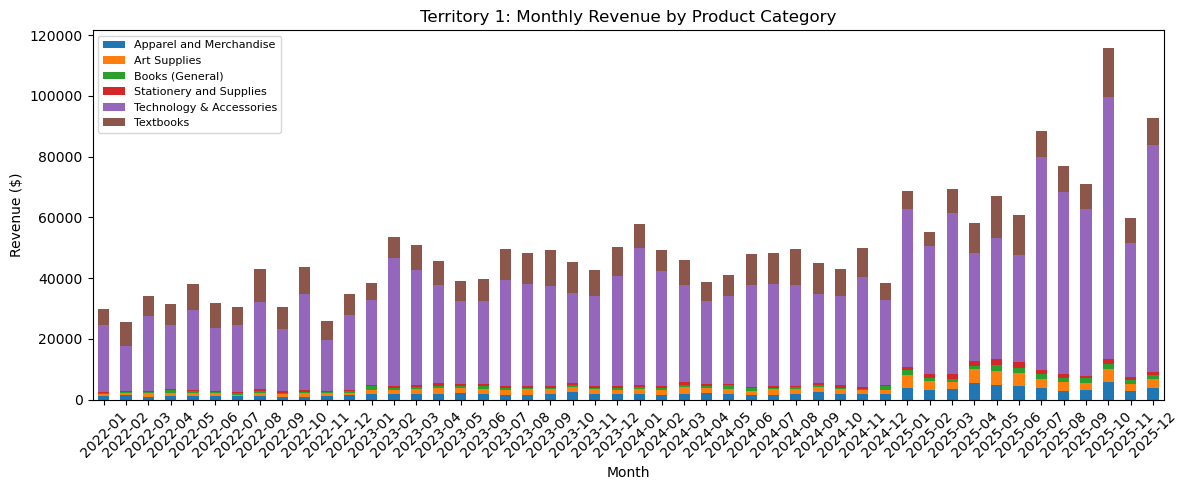

In [80]:
# Stacked bar by category
# Pivot and plot category revenue per month

t1_pivot = t1_cat_monthly.pivot_table(index='Month', columns='Category', values='Revenue', fill_value=0)
t1_pivot.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title('Territory 1: Monthly Revenue by Product Category')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()